<a href="https://colab.research.google.com/github/Kartik8625/Doctor_Visit_Analysis/blob/main/Doctor_Visit_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Case Study: Doctor Visit Analysis using Python
**Scope:** Basic Exploratory Data Analysis (EDA) on the Healthcare Analytics for Doctor Visits dataset.

**Dataset:** 5,190 individuals; survey of doctor visits, illness, insurance and income.

| Column | Meaning |
|---|---|
| `visits` | Number of doctor visits in the past 2 weeks |
| `gender` | male / female |
| `age` | Age in years divided by 100 (0.19 = 19 years) |
| `income` | Annual income in units of $10,000 (0.55 = $5,500) |
| `illness` | Number of illnesses in the past 2 weeks |
| `reduced` | Days of reduced activity in the past 2 weeks due to illness/injury |
| `health` | General health questionnaire score (higher = worse health) |
| `private` | Has private health insurance |
| `freepoor` | Free government insurance due to low income |
| `freerepat` | Free government insurance due to old age, disability or veteran status |
| `nchronic` | Chronic condition, not limiting activity |
| `lchronic` | Chronic condition, limiting activity |

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

## 1. Load the dataset and display first 15 rows

In [4]:
df = pd.read_csv("/content/1776250375-P2-Healthcare Analytics for Doctor Visits.csv")
df.head(15)

,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
0,1,1,female,0.19,0.55,1,4,1,yes,no,no,no,no
1,2,1,female,0.19,0.45,1,2,1,yes,no,no,no,no
2,3,1,male,0.19,0.90,3,0,0,no,no,no,no,no
3,4,1,male,0.19,0.15,1,0,0,no,no,no,no,no
4,5,1,male,0.19,0.45,2,5,1,no,no,no,yes,no
5,6,1,female,0.19,0.35,5,1,9,no,no,no,yes,no
6,7,1,female,0.19,0.55,4,0,2,no,no,no,no,no
7,8,1,female,0.19,0.15,3,0,6,no,no,no,no,no
8,9,1,female,0.19,0.65,2,0,5,yes,no,no,no,no
9,10,1,male,0.19,0.15,1,0,0,yes,no,no,no,no


## 2. Display complete information about the columns: column name, count, data type and overall memory usage

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5190 entries, 0 to 5189
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  5190 non-null   int64  
 1   visits      5190 non-null   int64  
 2   gender      5190 non-null   object 
 3   age         5190 non-null   float64
 4   income      5190 non-null   float64
 5   illness     5190 non-null   int64  
 6   reduced     5190 non-null   int64  
 7   health      5190 non-null   int64  
 8   private     5190 non-null   object 
 9   freepoor    5190 non-null   object 
 10  freerepat   5190 non-null   object 
 11  nchronic    5190 non-null   object 
 12  lchronic    5190 non-null   object 
dtypes: float64(2), int64(5), object(6)
memory usage: 527.2+ KB


The first column (`Unnamed: 0`) is just the row index saved by the CSV export; it carries no information, so we drop it.

In [6]:
df = df.drop(columns="Unnamed: 0")
print("Shape:", df.shape)
df.describe()

Shape: (5190, 12)


,visits,age,income,illness,reduced,health
count,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000
mean,0.301734,0.406385,0.583160,1.431985,0.861850,1.217534
std,0.798134,0.204782,0.368907,1.384152,2.887628,2.124266
min,0.000000,0.190000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.220000,0.250000,0.000000,0.000000,0.000000
50%,0.000000,0.320000,0.550000,1.000000,0.000000,0.000000
75%,0.000000,0.620000,0.900000,2.000000,0.000000,2.000000
max,9.000000,0.720000,1.500000,5.000000,14.000000,12.000000


## 3. Check for missing values and duplicates

In [7]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Missing values per column:
visits       0
gender       0
age          0
income       0
illness      0
reduced      0
health       0
private      0
freepoor     0
freerepat    0
nchronic     0
lchronic     0
dtype: int64

Duplicate rows: 1320


## 4. Visualize missing values using a heatmap

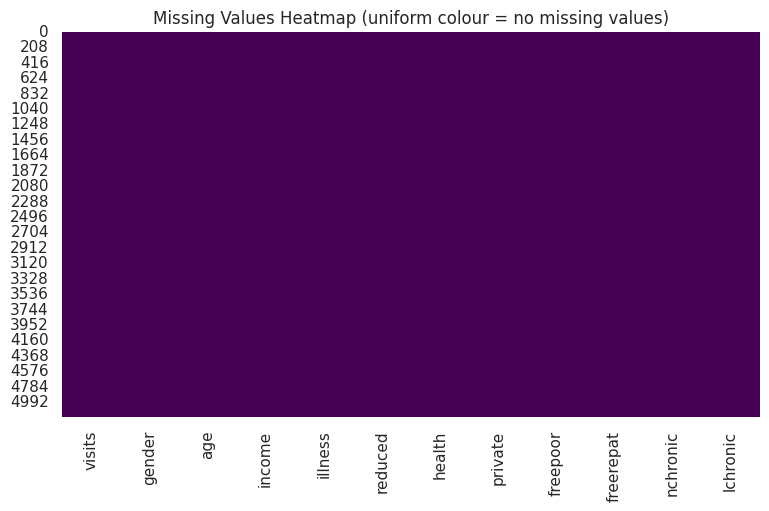

In [8]:
plt.figure(figsize=(9, 5))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap (uniform colour = no missing values)")
plt.show()

## 5. Find out the total number of people based on their count of illness

illness
0    1554
1    1638
2     946
3     542
4     274
5     236
Name: count, dtype: int64


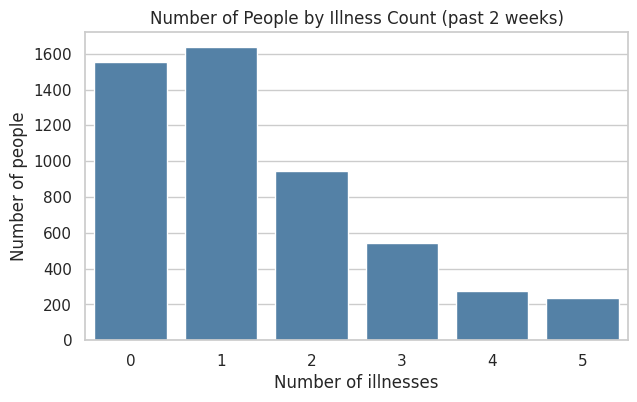

In [9]:
illness_counts = df["illness"].value_counts().sort_index()
print(illness_counts)

plt.figure(figsize=(7, 4))
sns.countplot(x="illness", data=df, color="steelblue")
plt.title("Number of People by Illness Count (past 2 weeks)")
plt.xlabel("Number of illnesses")
plt.ylabel("Number of people")
plt.show()

## 6. Count the number of males and females

gender
female    2702
male      2488
Name: count, dtype: int64


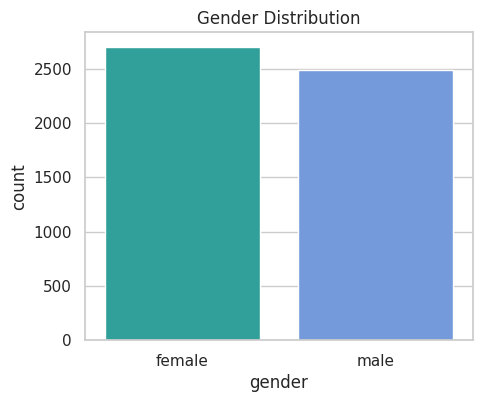

In [10]:
print(df["gender"].value_counts())

plt.figure(figsize=(5, 4))
sns.countplot(x="gender", data=df, hue="gender", palette=["lightseagreen", "cornflowerblue"], legend=False)
plt.title("Gender Distribution")
plt.show()

## 7. Visualize and analyse the maximum, minimum and median income

Minimum income: 0.0
Median income : 0.55
Maximum income: 1.5


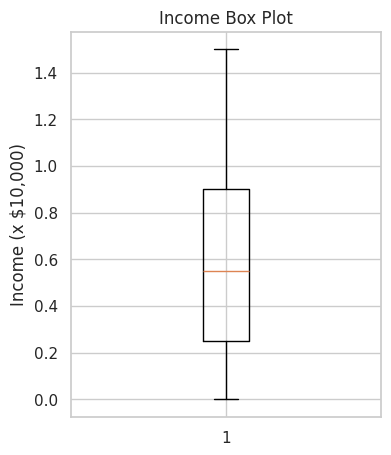

In [11]:
print("Minimum income:", df["income"].min())
print("Median income :", df["income"].median())
print("Maximum income:", df["income"].max())

plt.figure(figsize=(4, 5))
plt.boxplot(df["income"])
plt.title("Income Box Plot")
plt.ylabel("Income (x $10,000)")
plt.show()

## 8. Find out the number of days of reduced activity of males and females separately due to illness

In [12]:
reduced_by_gender = df.groupby("gender")["reduced"].agg(total_days="sum", avg_days="mean").round(2)
reduced_by_gender

,total_days,avg_days
gender,,
female,2636,0.98
male,1837,0.74


## 9. Plot a horizontal bar chart to analyse the reduced days of activity due to illness based on gender

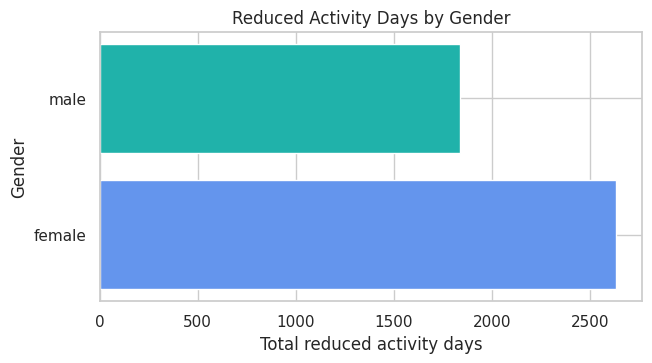

In [13]:
db = df.groupby("gender")["reduced"].sum().to_frame().reset_index()

plt.figure(figsize=(7, 3.5))
plt.barh(db["gender"], db["reduced"], color=["cornflowerblue", "lightseagreen"])
plt.title("Reduced Activity Days by Gender")
plt.xlabel("Total reduced activity days")
plt.ylabel("Gender")
plt.show()

## 10. Count and visualize the number of males and females affected by illness

gender
female    2023
male      1613
Name: count, dtype: int64


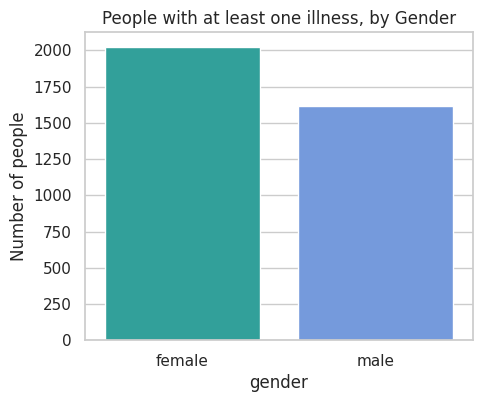

In [14]:
affected = df[df["illness"] > 0]["gender"].value_counts()
print(affected)

plt.figure(figsize=(5, 4))
sns.countplot(x="gender", data=df[df["illness"] > 0], hue="gender",
              palette=["lightseagreen", "cornflowerblue"], legend=False)
plt.title("People with at least one illness, by Gender")
plt.ylabel("Number of people")
plt.show()

## 11. Find the correlation between variables in the dataset

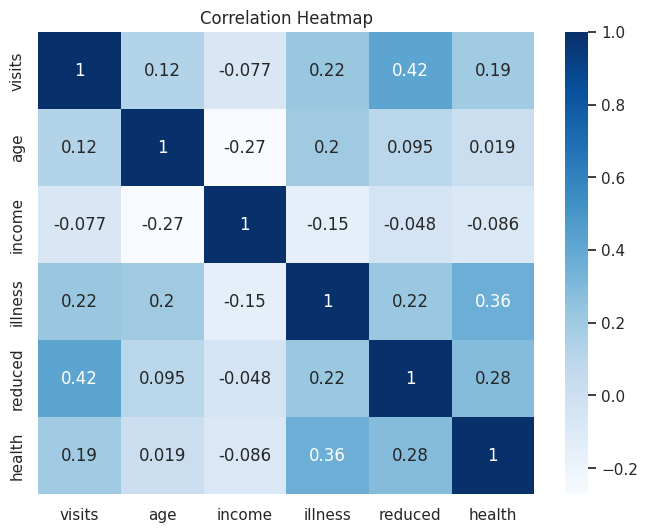

In [15]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), cbar=True, annot=True, cmap="Blues")
plt.title("Correlation Heatmap")
plt.show()

## 12. Analyse how the income of a patient affects the number of visits to the doctor

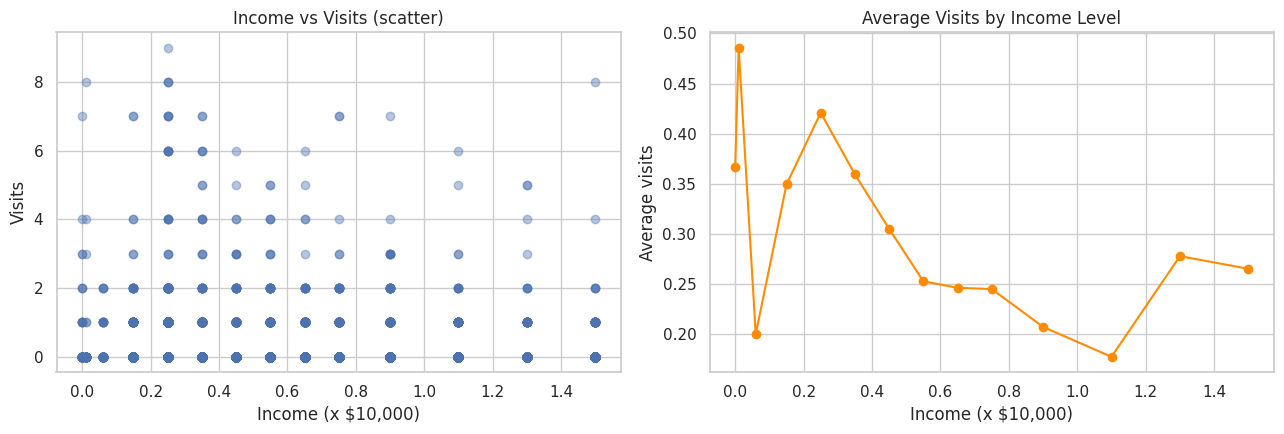

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

ax[0].scatter(x="income", y="visits", data=df, alpha=0.4)
ax[0].set_xlabel("Income (x $10,000)")
ax[0].set_ylabel("Visits")
ax[0].set_title("Income vs Visits (scatter)")

avg_visits = df.groupby("income")["visits"].mean()
ax[1].plot(avg_visits.index, avg_visits.values, marker="o", color="darkorange")
ax[1].set_xlabel("Income (x $10,000)")
ax[1].set_ylabel("Average visits")
ax[1].set_title("Average Visits by Income Level")

plt.tight_layout()
plt.show()

## 13. Visualize the percentage of people with government health insurance (low income; old age/disability/veteran) and with private health insurance

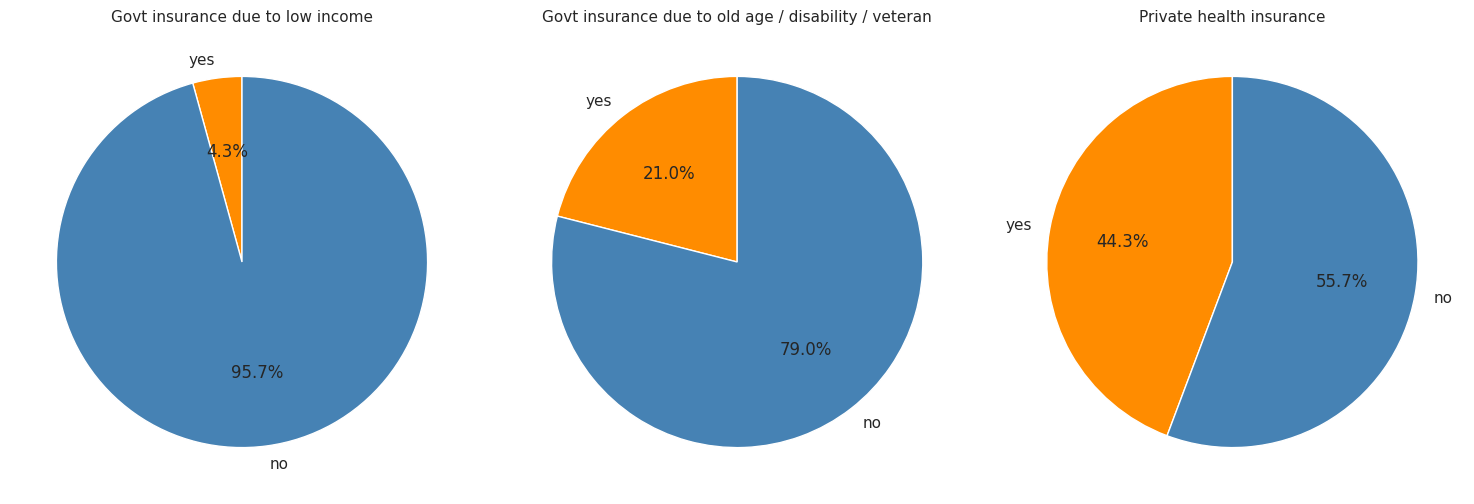

In [17]:
cols = {
    "freepoor":  "Govt insurance due to low income",
    "freerepat": "Govt insurance due to old age / disability / veteran",
    "private":   "Private health insurance",
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (col, title) in zip(axes, cols.items()):
    counts = df[col].value_counts().reindex(["yes", "no"])
    ax.pie(counts, labels=counts.index, autopct="%1.1f%%", startangle=90,
           colors=["darkorange", "steelblue"])
    ax.set_title(title, fontsize=11)
plt.tight_layout()
plt.show()

## 14. Additional basic EDA: age distribution and visits by illness count

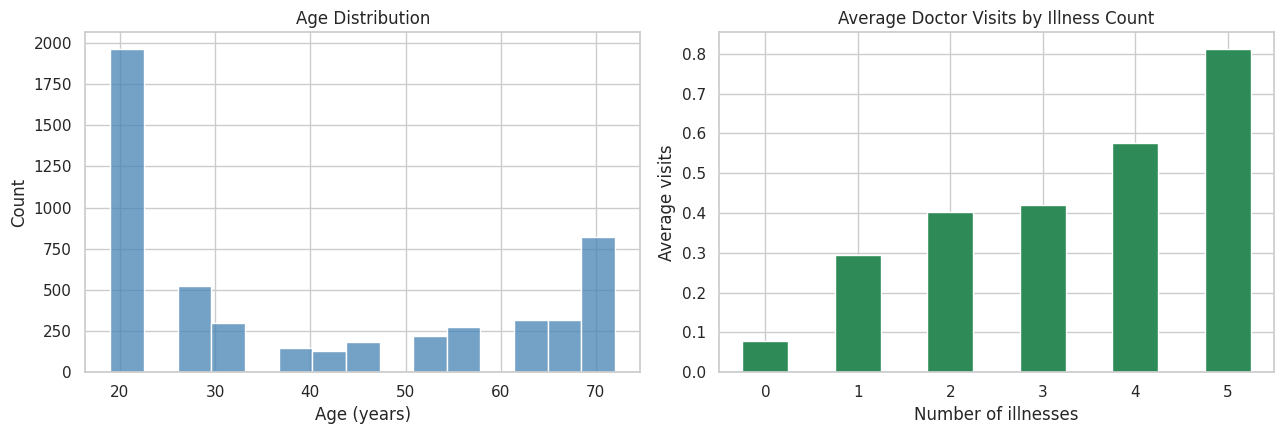

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot((df["age"] * 100), bins=15, color="steelblue", ax=ax[0])
ax[0].set_title("Age Distribution")
ax[0].set_xlabel("Age (years)")

df.groupby("illness")["visits"].mean().plot(kind="bar", color="seagreen", ax=ax[1])
ax[1].set_title("Average Doctor Visits by Illness Count")
ax[1].set_xlabel("Number of illnesses")
ax[1].set_ylabel("Average visits")
ax[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

## 15. Key Insights
- **Data quality:** 5,190 records, 12 columns after dropping the index; **no missing values, no duplicates**.
- **Gender:** 2,702 females (52%) vs 2,488 males (48%), a roughly balanced sample.
- **Illness:** ~70% of people reported at least one illness in the past 2 weeks; 1 illness is the most common (1,638 people); 236 reported 5.
- **Income:** minimum 0, median 0.55, maximum 1.5 (x $10,000). Most people sit in the low-to-mid income range.
- **Reduced activity:** females lost more days (2,636 total, 0.98 avg) than males (1,837 total, 0.74 avg). Only ~14% had any reduced-activity days, but 188 people were at the 14-day maximum.
- **Doctor visits:** only ~20% visited a doctor in the 2 weeks; average visits rise steadily with illness count (0.08 for 0 illnesses to 0.81 for 5).
- **Correlation:** strongest link is `visits` and `reduced` (0.42), then `illness` and `health` (0.36). Income has a weak negative relation with visits (-0.08); age has a negative relation with income (-0.27).
- **Insurance:** 44% have private insurance, 21% have govt cover (old age/disability/veteran), 4% have govt cover due to low income.
- **Chronic conditions:** people with an activity-limiting chronic condition average 0.60 visits vs 0.26 without.

*Note: correlation does not imply causation; these are descriptive findings only.*